MIEMBROS DEL GRUPO:

QISONG WANG, 100522127

XUECHENG ZHANG, 100522197

In [1]:
%pip install pandas numpy scikit-learn matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Importación de los paquetes necesarios

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


# Semilla 
RANDOM_STATE = 100522127

# 2. EDA SIMPLIFICADO

In [3]:
df = pd.read_pickle("bank_09.pkl")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
df.shape
df.info()

<class 'pandas.DataFrame'>
Index: 11000 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11000 non-null  int64 
 1   job        10903 non-null  object
 2   marital    10718 non-null  object
 3   education  11000 non-null  object
 4   default    11000 non-null  object
 5   balance    11000 non-null  int64 
 6   housing    11000 non-null  object
 7   loan       11000 non-null  object
 8   contact    11000 non-null  object
 9   day        11000 non-null  int64 
 10  month      11000 non-null  object
 11  duration   11000 non-null  int64 
 12  campaign   11000 non-null  int64 
 13  pdays      11000 non-null  int64 
 14  previous   11000 non-null  int64 
 15  poutcome   11000 non-null  object
 16  deposit    11000 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.5+ MB


In [5]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

print("Numéricas:", len(num_cols))
print("Categóricas:", len(cat_cols))

Numéricas: 7
Categóricas: 10


In [6]:
for col in cat_cols:
    print(col, df[col].nunique())

job 12
marital 3
education 4
default 2
housing 2
loan 2
contact 3
month 12
poutcome 4
deposit 2


In [7]:
df.isnull().sum()

age            0
job           97
marital      282
education      0
default        0
balance        0
housing        0
loan           0
contact        0
day            0
month          0
duration       0
campaign       0
pdays          0
previous       0
poutcome       0
deposit        0
dtype: int64

In [8]:
df.nunique()

age            76
job            12
marital         3
education       4
default         2
balance      3783
housing         2
loan            2
contact         3
day            31
month          12
duration     1423
campaign       36
pdays         472
previous       34
poutcome        4
deposit         2
dtype: int64

In [9]:
# Contar número de valores para determinar si el árbol está desbalanceado
df["deposit"].value_counts()

deposit
no     5780
yes    5220
Name: count, dtype: int64

In [10]:
df = pd.read_pickle("bank_09.pkl")

# Creación de nuevo atributo contacted, y reemplazo de -1 a 0 en pdays
df["contacted"] = (df["pdays"] != -1).astype(int)
df["pdays"] = df["pdays"].replace(-1, 0)

df.head(11000)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,contacted
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,0,0,unknown,yes,0
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,0,0,unknown,yes,0
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,0,0,unknown,yes,0
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,0,0,unknown,yes,0
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,0,0,unknown,yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,0,0,unknown,no,0
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,0,0,unknown,no,0
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,0,0,unknown,no,0
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no,1


En el dataset cargado tiene 11000 instancias de clientes del banco. Además cuenta con 17 variables, de las cuales encontramos tanto atributos categóricos (10 variables) como numéricos (7 variables).

Se puede comprobar que de las variables categóricas, las variables job y month son de alta cardinalidad, ambas con 12 valores distintas. 

En cuanto a los missing values, se puede observar que las variables job y marital cuentan con valores faltantes. 

También se ha observado que dicho dataset no cuenta con ningún valor constante, por lo que no hay ninguna variable que nos pueda resultar inútil.

Se trata de un problema de clasificación, pues con este dataset se pretende determinar si se realizará un préstamo. 

Se ha analizado la distribución de la variable objetivo y se observa que ambas clases presentan una proporción relativamente similar (5780 no; 5220 yes), por lo que el dataset no presenta un desbalanceo significativo entre las clases.

Por último, se ha realizado un análisis de la variable pdays, el cual indica el número de días transcurridos desde que se contactó a un cliente. Sin embargo alguno de sus valores indican -1, significando que el cliente nunca fue contactado. Para tratar este atributo, se ha decidido emplear un nuevo atributo denominado "contacted", el cual indica si un cliente fue contactado alguna vez o no. Los valores -1 de pdays se reemplazan por un 0.  






# 3. DECIDIR CÓMO SE VA A REALIZAR LA EVALUACIÓN
En este apartado comienza el entrenamiento del modelo. En primer lugar se decidirá cómo será la evaluación del modelo, para ello se ha realizado un holdout, donde 2/3 se usará como train(entrenamiento) y el 1/3 se usará como test(prueba) para la estimación del rendimiento futuro(evaluación outer). Para la evaluación inner, se usará el crossvalidation(validación cruzada), con el acurracy como métrica principal.

In [11]:

x = df.drop(columns = "deposit")
y = df["deposit"]
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size =1/3, random_state=RANDOM_STATE)


# 4. MÉTODOS BÁSICOS: KNN Y TREES

### 4.1 Elección del scaler

En este apartado, se probará los distintos scalers (métodos de escalados), para ver entender cuál es el mejor para los datos seleccionados.

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Preprocesado
numerical_features = X_train.select_dtypes(exclude='object').columns
categorical_features = X_train.select_dtypes(include='object').columns

# Aplicamos el one-hot encoding y la imputación a los atributo categóricos. 
preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features),
        ('numerical', 'passthrough', numerical_features)
    ]
)

# Scalers
min_max_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

# Entrenamiento de modelo con cada scaler 
pipeline_knn_min_max = Pipeline([
    ('preprocessor', preprocessor), 
    ('scaler', min_max_scaler), 
    ('knn', KNeighborsClassifier())
])

pipeline_knn_stantard = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', standard_scaler), 
    ('knn', KNeighborsClassifier())
])

pipeline_knn_robust = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', robust_scaler), 
    ('knn', KNeighborsClassifier())
])

# Determinación de mejor scaler 
scores_min_max = cross_val_score(pipeline_knn_min_max, X_train, Y_train, cv=3, scoring='accuracy')
scores_standard = cross_val_score(pipeline_knn_stantard, X_train, Y_train, cv=3, scoring='accuracy')
scores_robust = cross_val_score(pipeline_knn_robust, X_train, Y_train, cv=3, scoring='accuracy')

media_min_max = np.mean(scores_min_max)
media_standard = np.mean(scores_standard)
media_robust = np.mean(scores_robust)

medias = [media_min_max, media_standard, media_robust]
scalers = ["Min max scaler", "Stardardization scaler", "Robust scaler"]

print("Min max scaler: ", media_min_max)
print("Stardardization scaler: ", media_standard)
print("Robust scaler: ", media_robust)

best_scaler = np.max(medias)
x = medias.index(best_scaler)
print("El mejor scaler es:", scalers[x])


Min max scaler:  0.7216684684443462
Stardardization scaler:  0.7504427464223835
Robust scaler:  0.7910819814422477
El mejor scaler es: Robust scaler


Tras realizar el proceso de elección de escalado, se puede observar que el mejor scaler para nuestro dataset es el Robust Scaler, ya me presenta una media superior respecto de los otros dos métodos, con una precisión del 0,79, aproximadamente.

### 4.2 MÉTODOS: KNN Y TREES

Aquí se importa la librería de tiempo, nececesario para calcular el tiempo que se tarda cada entrenamiento.

In [13]:
import time

### KNN CON DEFAULT H.P


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score

cv = KFold(n_splits=3, shuffle=True, random_state = RANDOM_STATE)

pipeline_default_knn = Pipeline ([
    ('preprocessor', preprocessor),
    ('scaler', robust_scaler),
    ('knn', KNeighborsClassifier())
])

tiempo_inicial = time.time()
best_score_default_knn = cross_val_score(pipeline_default_knn, 
                                         X_train, Y_train,
                                          cv=cv,
                                          scoring='accuracy')

tiempo_final = time.time()
tiempo_total = tiempo_final - tiempo_inicial

print(f"La precisión de KNN es: {best_score_default_knn.mean()}")
print(f"Tiempo total de entrenamiento: {tiempo_total}")




La precisión de KNN es: 0.7880821052795991
Tiempo total de entrenamiento: 0.13564443588256836


### KNN CON HPO


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

pipeline_knn_hpo = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', robust_scaler),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 23]
}

grid_knn = GridSearchCV(
    estimator=pipeline_knn_hpo,
    param_grid=param_grid_knn,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

tiempo_inicial = time.time()
grid_knn.fit(X_train, Y_train)
tiempo_final = time.time()
tiempo_total = tiempo_final - tiempo_inicial

print(f"Mejor precisión de KNN con HPO: {grid_knn.best_score_}")
print(f"El mejor hiper parámetros es: {grid_knn.best_params_}")
print(f"Tiempo total de entrenamiento: {tiempo_total}")

Mejor precisión de KNN con HPO: 0.8013088269255872
El mejor hiper parámetros es: {'knn__n_neighbors': 17}
Tiempo total de entrenamiento: 3.2044084072113037


### TREE CON DEFAULT H.P

In [16]:
from sklearn import tree
from sklearn.model_selection import KFold

pipeline_default_tree = Pipeline([
    ('preprocessor', preprocessor), 
    ('tree', tree.DecisionTreeClassifier(random_state=RANDOM_STATE))])

cv = KFold(n_splits=3, shuffle=True, random_state = RANDOM_STATE)

tiempo_inicial = time.time()
best_score_default_tree = cross_val_score(pipeline_default_tree, 
                                          X_train, Y_train, 
                                          cv=cv, 
                                          scoring='accuracy' )
tiempo_final = time.time()
tiempo_total = tiempo_final - tiempo_inicial

print(f"La precisión del árbol es: {best_score_default_tree.mean()}")
print(f"Tiempo total de entrenamiento: {tiempo_total}")


La precisión del árbol es: 0.7833080638197464
Tiempo total de entrenamiento: 0.14367961883544922


### TREE CON HPO

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

pipeline_tree_hpo = Pipeline([
    ('preprocessor', preprocessor),
    ('tree', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

param_grid_tree = {
    'tree__criterion': ['gini', 'entropy'],
    'tree__max_depth': [5, 8, 10, 15, 20, 23],
    'tree__min_samples_split': [15, 20, 30, 50, 110],
    'tree__min_impurity_decrease': [0.0, 0.001, 0.01]
}

grid_tree = GridSearchCV(
    estimator=pipeline_tree_hpo,
    param_grid=param_grid_tree,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

tiempo_inicial = time.time()

grid_tree.fit(X_train, Y_train)

tiempo_final = time.time()
tiempo_total = tiempo_final - tiempo_inicial

print(f"Mejor precisión de Tree con HPO: {grid_tree.best_score_}")
print(f"Los mejores hiper parámetros son: {grid_tree.best_params_}")
print(f"Tiempo total de entrenamiento: {tiempo_total}")

Mejor precisión de Tree con HPO: 0.8384020742198525
Los mejores hiper parámetros son: {'tree__criterion': 'gini', 'tree__max_depth': 15, 'tree__min_impurity_decrease': 0.001, 'tree__min_samples_split': 15}
Tiempo total de entrenamiento: 2.3108279705047607


### EFECTOS DE LOS DISTINTOS VALORES DE LOS HIPER-PARÁMETROS EN EL RESULTADO FINAL (mediante PLOTS)

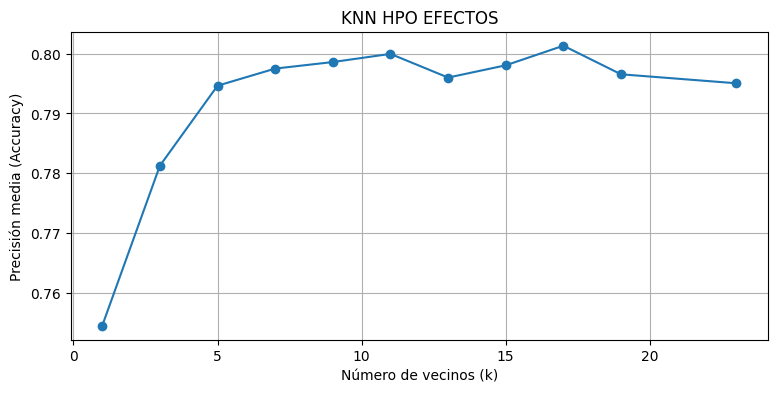

In [18]:
import matplotlib.pyplot as plt

resultados_knn = pd.DataFrame(grid_knn.cv_results_)

plt.figure(figsize=(9, 4))
plt.plot(resultados_knn['param_knn__n_neighbors'], resultados_knn['mean_test_score'], marker='o', linestyle='-')

plt.title('KNN HPO EFECTOS')
plt.xlabel('Número de vecinos (k)')
plt.ylabel('Precisión media (Accuracy)')
plt.grid(True)
plt.show()

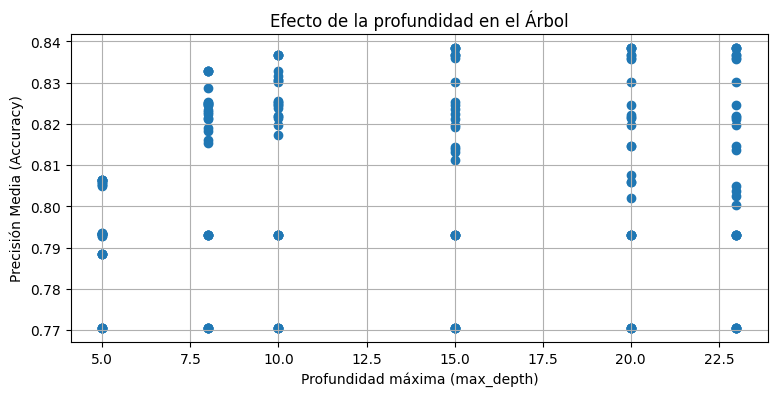

In [19]:
resultados_tree = pd.DataFrame(grid_tree.cv_results_)

plt.figure(figsize=(9, 4))
plt.scatter(resultados_tree['param_tree__max_depth'], resultados_tree['mean_test_score'], marker='o')

plt.title('Efecto de la profundidad en el Árbol')
plt.xlabel('Profundidad máxima (max_depth)')
plt.ylabel('Precisión Media (Accuracy)')

plt.grid(True)
plt.show()

En la gráfica de algoritmo KNN, se observa cómo afecta el número de vecinos al rendimiento del modelo. En un principio, con valores bajos se observa en la gráfica (k=1 y k=3), el modelo sufre problemas de overfitting(sobreajuste), donde las instancias son muy ruidosas tienen mucha influencia, y el modelo fallará en muchas ocasiones como se observa en el acurracy(precisión). Sin embargo, para k con valores más altos (k=11) al cosiderar más vecinos, los instancias ruidosas tienen menos influencia y el modelo tiende a acertar más. Cabe mencionar, que a medida que se vaya aumentando el valor de k, la precisión disminuye, ya que el modelo sufre problemas de underfitting(subajuste) y tiende a fallar más.

En el gráfica del algoritmo de árboles, se visualiza el impacto de la profundidad del árbol en la precisión del modelo, considerando también todas las combinaciones probadas. Se observa que con una profundidad máxima del árbol de 5, es modelo es demasiado simple, ya que no consigue entender bien los patrones de los datos, obteniendo una precisión inferior que el resto, lo que indica underfitting(subjaste) del modelo. Sin embargo, al aumentar el valor de la pronfundidad a 8 o 10, el rendimiento obtiene una mejora bastante significativa, alcanzando prácticamente los valores más altos respecto de las otros valores, por ende, se ha considerado que este será el punto óptimo de generalización. Finalmente, cabe mencionar, que la profundidad siga crenciendo (15, 20 , 23), la precisión máxima obtenida, deja de que ser constante, decrementando poco a poco, debido a que el modelo estaría sobreajustando, donde el árbol se volvería demasiado complejo.

### MODELO DUMMY

In [20]:
from sklearn.dummy import DummyClassifier

pipeline_dummy = Pipeline([
    ('preprocessor', preprocessor),
    ('dummy', DummyClassifier(strategy='most_frequent'))
])

tiempo_inicial = time.time()
scores_dummy = cross_val_score(
    pipeline_dummy, 
    X_train, Y_train, 
    cv=cv, 
    scoring='accuracy'
)

tiempo_final = time.time()
tiempo_total = tiempo_final - tiempo_inicial

print(f"Precisión media del modelo Dummy: {scores_dummy.mean()}")
print(f"Tiempo total de entrenamiento: {tiempo_total}")

Precisión media del modelo Dummy: 0.5247511259715932
Tiempo total de entrenamiento: 0.06147170066833496


Para comprobar que el modelo generado está aprendiendo sobre patrones útiles, se ha creado un modelo Dummy que siempre predice la clase mayoritaria, el cual, ha obtenido una precisión media del 52,4%. Dado que modelos KNN con HPO y Tree con HPO, tienen una precisión del 80.1% y 83.8% respectivamente. Con esto se puede concluir que ambos modelos extraen información importante respecto del modelo trivial/naive/dummy. Cabe destacar que, el coste computacional es superior de estos dos modelos es ligeramente superior al del modelo trivial, pero la precisión es significativamente superior lo que lo compensa.

# 5. MÉTODOS AVANZADOS: MODELOS LINEALES Y SVMS

### MODELO LINEAL SIN REGULARIZACIÓN

In [21]:
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', robust_scaler),
    ('lr', LogisticRegression(penalty=None, max_iter=1000, random_state=RANDOM_STATE))
])

tiempo_inicial = time.time()
scores_lr = cross_val_score(
    pipeline_lr, 
    X_train, Y_train, 
    cv=cv, 
    scoring='accuracy',
    n_jobs=-1
)
tiempo_final = time.time()

tiempo_total = tiempo_final - tiempo_inicial

print(f"Precisión de Regresión Logística SIN Regularización: {scores_lr.mean()}")
print(f"Tiempo total de entrenamiento: {tiempo_total}")

Precisión de Regresión Logística SIN Regularización: 0.8340388157579125
Tiempo total de entrenamiento: 0.08773040771484375


### MODELO LINEAL CON REGULARIZACIÓN

In [22]:
from sklearn.model_selection import GridSearchCV

# POR OMISIÓN
pipeline_lr_default = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', robust_scaler),
    ('lr', LogisticRegression(penalty='l1', solver='liblinear', random_state=RANDOM_STATE))
])

tiempo_inicial = time.time()
scores_lr_default = cross_val_score(pipeline_lr_default, X_train, Y_train, cv=cv, scoring='accuracy', n_jobs=-1)
tiempo_final = time.time()

tiempo_total = tiempo_final - tiempo_inicial

print(f"Precisión RL con L1 (Default C=1.0): {scores_lr_default.mean()}")
print(f"Tiempo de entrenamiento (Default): {tiempo_total}")

# CON HPO
param_grid_lr = {'lr__C': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_lr_l1 = GridSearchCV(
    estimator=pipeline_lr_default,
    param_grid=param_grid_lr,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

tiempo_inicial = time.time()
grid_lr_l1.fit(X_train, Y_train)
tiempo_final = time.time()

tiempo_total = tiempo_final - tiempo_inicial

print(f"Mejor precisión de RL L1 con HPO: {grid_lr_l1.best_score_}")
print(f"Mejores hiperparámetros: {grid_lr_l1.best_params_}")
print(f"Tiempo total de entrenamiento HPO: {tiempo_total}")

Precisión RL con L1 (Default C=1.0): 0.8349934232325564
Tiempo de entrenamiento (Default): 0.06734466552734375
Mejor precisión de RL L1 con HPO: 0.8349934232325564
Mejores hiperparámetros: {'lr__C': 1}
Tiempo total de entrenamiento HPO: 0.31188368797302246


c:\Users\headb\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\headb\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


### SVM CON DEFAULT H.P

In [23]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

pipeline_default_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', robust_scaler),
    ('svm', SVC(random_state=RANDOM_STATE))
])

tiempo_inicial = time.time()

default_svm = cross_val_score(
    pipeline_default_svm,
    X_train,
    Y_train,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

tiempo_final = time.time()
tiempo_total = tiempo_final - tiempo_inicial

print(f"La precisión de SVM es: {default_svm.mean()}")
print(f"Desviación típica: {default_svm.std()}")
print(f"Tiempo total de entrenamiento: {tiempo_total}")

La precisión de SVM es: 0.8382673034807221
Desviación típica: 0.011665382659141119
Tiempo total de entrenamiento: 0.685420036315918


### SVM CON HPO

In [24]:
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

pipeline_svm_hpo = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', robust_scaler),
    ('svm', SVC(random_state=RANDOM_STATE))
])

param_grid_svm = {
    'svm__kernel': ['linear', 'rbf'],
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': [0.01, 0.1, 1]
}

grid_svm = GridSearchCV(
    estimator=pipeline_svm_hpo,
    param_grid=param_grid_svm,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

tiempo_inicial = time.time()

grid_svm.fit(X_train, Y_train)

tiempo_final = time.time()
tiempo_total = tiempo_final - tiempo_inicial

print(f"Mejor precisión de SVM con HPO: {grid_svm.best_score_}")
print(f"Los mejores hiper-parámetros son: {grid_svm.best_params_}")
print(f"Tiempo total de entrenamiento: {tiempo_total}")

Mejor precisión de SVM con HPO: 0.8426310639859785
Los mejores hiper-parámetros son: {'svm__C': 100, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Tiempo total de entrenamiento: 44.67541527748108


### ATRIBUTOS MÁS IMPORTANTES

A continuación veremos los atributos más revantes:

In [25]:
mejor_modelo_l1 = grid_lr_l1.best_estimator_
preprocesador = mejor_modelo_l1.named_steps['preprocessor']
modelo_lr = mejor_modelo_l1.named_steps['lr']

feature_names = preprocesador.get_feature_names_out()

print("Atributos relevantes:")
for i, coef in enumerate(modelo_lr.coef_[0]):
    if coef != 0:
        print(f"{feature_names[i]} ({coef})")

Atributos relevantes:
categorical__job_admin. (0.1619731439281456)
categorical__job_blue-collar (-0.16755464266811732)
categorical__job_entrepreneur (-0.1830472782990261)
categorical__job_housemaid (-0.3967988607660841)
categorical__job_management (-0.05652903056712018)
categorical__job_retired (0.3150599836318597)
categorical__job_services (-0.07740918971535707)
categorical__job_student (0.6790158438937139)
categorical__job_None (4.324935259189274)
categorical__marital_married (-0.26646234224233445)
categorical__marital_None (4.855003098819242)
categorical__education_primary (-0.2842344097734235)
categorical__education_secondary (-0.05014463564031895)
categorical__education_tertiary (0.15067476476244443)
categorical__education_unknown (0.0002105497071162124)
categorical__default_no (0.00010363439306856606)
categorical__default_yes (-0.017707781407254652)
categorical__housing_no (0.33134289178279125)
categorical__housing_yes (-0.41318038047730454)
categorical__loan_no (0.51531826272122

# 6. RESULTADOS Y MODELO FINAL

### 6.1 SELECCIÓN DE LA MEJOR ALTENATIVA

Tras realizar la evaluación de las distintas alternativas en puntos posteriores, se concluye que la mejor altenativa será el algoritmo SVM con hiper-parámetros:
1. svc_C : 100
2. svm_gamma: 0.01
3. svm_kernel: 'rbf'

### 6.2 ESTIMACIÓN RENDIMIENTO FUTURO

A continuación se realizará los test para probar la accuracy("precisión") del modelo que se ha obtenido:

In [26]:
from sklearn.metrics import accuracy_score

mejor_modelo = grid_svm.best_estimator_

y_pred_test = mejor_modelo.predict(X_test)
precision_test = accuracy_score(Y_test, y_pred_test)

print(f"Estimación rendimiento futuro: {precision_test}")

Estimación rendimiento futuro: 0.8440141805290429


### 6.3 ENTRENAMIENTO DEL MODELO FINAL
Tras realizar el estimación de rendimiento futuro, cogemos todos los datos disponibles, para obtener el modelo final. La razón es  cuantos más datos se usen para entrenar el modelo, mejor será el modelo, por ende, el modelo siempre será ligeramente mejor, que el que se obtiene en el rendimiento a futuro.

In [27]:
pipeline_modelo_final = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', robust_scaler),
    ('svm', SVC(C=100, gamma=0.01, kernel='rbf', random_state=RANDOM_STATE))
])

x = df.drop(columns = "deposit")
y = df["deposit"]

tiempo_inicial = time.time()
pipeline_modelo_final.fit(x, y)
tiempo_final = time.time()

tiempo_total = tiempo_final - tiempo_inicial

print(f"Entrenamiento del modelo final completado")
print(f"Tiempo tras el entrenamiento del modelo final {tiempo_total}")

Entrenamiento del modelo final completado
Tiempo tras el entrenamiento del modelo final 2.8988873958587646


### 6.4 & 7. GUARDADO DEL MODELO PARA SU USO EN LA COMPETICIÓN Y EN LA INTERFAZ WEB (STREAMLIT)

In [28]:
import joblib

num_cols = x.select_dtypes(include=['number']).columns.tolist()
cat_cols = x.select_dtypes(include=['object']).columns.tolist()

feature_metadata = {}

for col in num_cols:
    s = x[col].dropna()
    feature_metadata[col] = {
        "type": "numerical",
        "min": float(s.min()),
        "max": float(s.max()),
        "median": float(s.median())
    }

for col in cat_cols:
    s = x[col].dropna()
    feature_metadata[col] = {
        "type": "categorical",
        "options": sorted(s.astype(str).unique().tolist())
    }

pack = {
    "pipeline": pipeline_modelo_final,
    "feature_metadata": feature_metadata,
    "classes_": pipeline_modelo_final.classes_.tolist()
}

joblib.dump(pack, 'modelo_final.joblib')
print("Modelo final guardado")

Modelo final guardado


### 7.1 PRUEBA DE VALIDACIÓN DE LA PREDICCIÓN ENTRE "PREDICCIÓN MEDIANTE CÓDIGO" Y "PREDICCIÓN MEDIANTE STREAMLIT"

In [29]:
datos_prueba = pd.DataFrame([
    {
        "age": 60, 
        "job": "management", 
        "marital": "single", 
        "education": "tertiary",
        "default": "no", 
        "balance": 4200, 
        "housing": "no", 
        "loan": "no",
        "contact": "cellular", 
        "day": 12, "month": "oct", 
        "duration": 950,
        "campaign": 2, 
        "pdays": 120, 
        "previous": 4, 
        "poutcome": "success", 
        "contacted": 1
    },
    {
        "age": 45, 
        "job": "services", 
        "marital": "married", 
        "education": "secondary",
        "default": "no", 
        "balance": 100, 
        "housing": "yes", 
        "loan": "no",
        "contact": "unknown", 
        "day": 20,
        "month": "may", 
        "duration": 60,
        "campaign": 4, 
        "pdays": 0, 
        "previous": 0, 
        "poutcome": "unknown", 
        "contacted": 0
    },
    {
        "age": 21, "job": 
        "student", 
        "marital": "single", 
        "education": "secondary",
        "default": "no", 
        "balance": 15000, 
        "housing": "no", 
        "loan": "no",
        "contact": "cellular", 
        "day": 31, 
        "month": "dec", 
        "duration": 1500,
        "campaign": 1, 
        "pdays": 300, 
        "previous": 5, 
        "poutcome": "success", 
        "contacted": 1
    },
    {
        "age": 85, 
        "job": "management", 
        "marital": "divorced", 
        "education": "unknown",
        "default": "yes", 
        "balance": -1200, 
        "housing": "yes", 
        "loan": "yes",
        "contact": "telephone", 
        "day": 1, 
        "month": "jan", 
        "duration": 10,
        "campaign": 15, 
        "pdays": 0, 
        "previous": 0, 
        "poutcome": "failure", 
        "contacted": 0
    }
])

prediccion_prueba = pipeline_modelo_final.predict(datos_prueba)

print("Prueba usuario 1 (Respuesta esperada: yes)", prediccion_prueba[0])
print("Prueba usuario 2 (Respuesta esperada: no)",prediccion_prueba[1])
print("Prueba usuario 3 (Respuesta esperada: yes)", prediccion_prueba[2])
print("Prueba usuario 4 (Respuesta esperada: no)",prediccion_prueba[3])

Prueba usuario 1 (Respuesta esperada: yes) yes
Prueba usuario 2 (Respuesta esperada: no) no
Prueba usuario 3 (Respuesta esperada: yes) yes
Prueba usuario 4 (Respuesta esperada: no) no


### 8. TAREA DE ELECCIÓN ABIERTA

Para la tarea extra se ha decidido hacer uno de los dos essemble que se ha aprendido en clase, concretamente el Gradient boosing. Se ha elegido esta tarea, ya que, hemos sentido curiosidad, por cómo se comporta este tipo de algoritmo que se autocorrige todo el tiempo, y por tanto, obteniendo una mejor precisión a la hora de predecir. Asimismo, al igual que el ejemplo que se ha visto en las diapositivas de clase, también hemos elegido el parámetro para scoring el "neg_log_loss", que sirve para evaluar la validez de la probabilidades que se ha devuelto.

In [30]:
from sklearn.ensemble import GradientBoostingClassifier

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

gb = Pipeline([
    ('preprocessor', preprocessor),
    ('gb', GradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid_gb = {
    'gb__n_estimators': [100, 200],
    'gb__learning_rate': [0.05, 0.1],
    'gb__max_depth': [2, 5, 10]
}

grid_gb = GridSearchCV(estimator=gb, param_grid=param_grid_gb, cv=cv, scoring='neg_log_loss', n_jobs=-1)

tiempo_inicial = time.time()
grid_gb.fit(X_train, Y_train)
tiempo_final = time.time()
tiempo_total = tiempo_final - tiempo_inicial

print(f"Mejor precisión de Gradient Boosting con HPO: {grid_gb.best_score_}")
print(f"Los mejores hiper-parámetros son: {grid_gb.best_params_}")
print(f"Tiempo total de entrenamiento: {tiempo_total}")

Mejor precisión de Gradient Boosting con HPO: -0.3357608031900446
Los mejores hiper-parámetros son: {'gb__learning_rate': 0.05, 'gb__max_depth': 5, 'gb__n_estimators': 200}
Tiempo total de entrenamiento: 12.881317377090454


### DECLARACIÓN USO DE LA IA GENERATIVA
Para el proyecto se ha usado la IA generativa en varios aspectos:


1. Revisión de que está todos los contenidos pedidos para la práctica

2. Guía y consejos para mejorar aspectos del código (refactorización)

3. Dudas acerca los errores emitidos, tras ejecutar el programa

4. Entender el código de propuesta de streamlit proporcionado por el profesorado